<a href="https://colab.research.google.com/github/ollihansen90/Mathe-SH/blob/main/Schiffeversenken_Termin8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚢 Schiffe Versenken - Termin 8
## Fragen?
Solltet ihr Fragen zum Code oder Probleme mit Colab haben, schickt uns gerne eine Mail:

*   h.hansen@uni-luebeck.de
*   mika.kohlhammer@student.uni-luebeck.de
*   gun.ingwersen@student.uni-luebeck.de

## 🤖 Unsere KI übernimmt das Ruder! 🚢💡

In den letzten Terminen haben wir unser Spiel **Schiffe versenken** Schritt für Schritt aufgebaut.  
Unser Spielfeld funktioniert, Schiffe können platziert werden, und wir können Treffer und Fehlversuche erkennen. 🎯💥

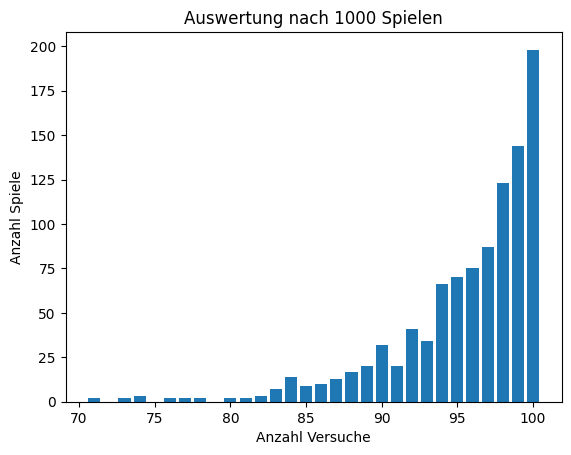

In [1]:
# utils.py (möglicherweise als eigene Datei zum Importieren, siehe bspw. https://github.com/ollihansen90/Mathe-SH/blob/main/SudokuSolver.ipynb)
import random
import matplotlib.pyplot as plt

def reset_spielfeld():
    # Erstellt ein leeres Spielfeld
    return [[0 for i in range(10)] for j in range(10)]

def male_feld(feld):
    # Zeichnet das Spielfeld auf der Konsole
    print("  │ 1 2 3 4 5 6 7 8 9 0 │\n──┼─────────────────────┼─");alphabet = "abcdefghijklmnopqrstuvwxyz"
    for i, zeile in enumerate(feld):
        string = alphabet[i] + " │ "
        for zeichen in zeile: string = string+["\x1b[34m~\x1b[30m", "s", "\x1b[31mx\x1b[30m", "t", "z"][zeichen] + " "
        string = string + "│";print(string)
    print("──┼─────────────────────┼─")

def setze_schiff(feld, pos, dir, l):
    # Setzt Schiff in das Spielfeld
    #   pos: Koordinaten, [int, int]
    #   dir: Ausrichtung, 0 horizontal (waagerecht), 1 vertikal (senkrecht), int
    #   l: Länge, int
    for i in range(l):
        if dir==0:
            feld[pos[0]][pos[1]+i] = 1
        else:
            feld[pos[0]+i][pos[1]] = 1
    return feld

def padding(feld):
    # Rahmen mit Nullen
    #   feld: Spielfeld, Liste von Listen
    output = [[0 for i in range(12)] for j in range(12)]
    for i in range(10):
        for j in range(10): output[i+1][j+1] = feld[i][j]
    return output

def erlaubt(feld, dir, l):
    # Erstellt für gegebenes Feld die möglichen Startposition eines Schiffes
    #   feld: Spielfeld, Liste von Listen mit int
    #   dir: Ausrichtung, 0 horizontal (waagerecht), 1 vertikal (senkrecht), int
    #   l: Länge, int
    hilfsfeld = [[1 for i in range(10)] for j in range(10)]
    p_feld = padding(feld)
    # Rand
    if dir==0:
        for zeile in range(10):
            for spalte in range(10-l+1, 10):
                hilfsfeld[zeile][spalte] = 0
    else:
        for zeile in range(10-l+1, 10):
            for spalte in range(10): hilfsfeld[zeile][spalte] = 0
    # Schiff-Nachbarn
    for zeile in range(10):
        for spalte in range(10): # Tile zeile, spalte
            #if hilfsfeld[zeile][spalte] == 0:
            #    continue
            summe = 0
            for kx in range(3): # k für Kernel
                for ky in range(3):
                    summe = summe + p_feld[zeile+kx][spalte+ky]

            if summe>0:
                hilfsfeld[zeile][spalte] = 2

    # Crash
    for zeile in range(10):
        for spalte in range(10): # Tile zeile, spalte
            if hilfsfeld[zeile][spalte]==2:
                for i in range(1, l):
                    if dir==1 and zeile-i>=0:
                        hilfsfeld[zeile-i][spalte] = 3
                    elif dir==0 and spalte-i>=0:
                        hilfsfeld[zeile][spalte-i] = 3

    output = []
    for x in range(len(hilfsfeld)):
        for y in range(len(hilfsfeld[x])):
            if hilfsfeld[x][y] == 1: output.append([x, y])
    return output

def generiere_spielfeld(schiffe=[5,4,3,3,2]):
    # Erstellt ein leeres Spielfeld und setzt Schiffe rein
    #   schiffe: Liste von Schifflängen
    spielfeld = reset_spielfeld()
    for l in schiffe:
        dir = random.randint(0,1)
        erlaubtliste = erlaubt(spielfeld, dir, l)
        pos = erlaubtliste[random.randint(0,len(erlaubtliste)-1)]
        spielfeld = setze_schiff(spielfeld, pos, dir, l)
    return spielfeld

def eingabe():
    # Lässt den Spieler eine Position auswählen
    eingabe = ""
    while not gueltig(eingabe): eingabe = input("Wähle ein Feld: ").lower()
    output = False
    for i in range(10):
        if eingabe[0]=="abcdefghij"[i]: output = [i,(int(eingabe[1])-1)%10]
    return output

def spiel_ende(spielfeld, loesung):
    # Bestimmt, ob ein Spiel beendet ist. Spiel ist beendet, wenn alle Schiffe gefunden wurden
    #   spielfeld, loesung: Liste von Listen mit int
    for zeile in range(len(loesung)):
        if 1 not in loesung[zeile]: continue
        for spalte in range(len(loesung[0])):
            if loesung[zeile][spalte]==1 and spielfeld[zeile][spalte]==0: return False
    return True

def gueltig(eingabe):
    # Überprüft, ob eine Eingabe legal ist.
    #   eingabe: String
    return len(eingabe)==2 and eingabe[0] in "abcdefghij" and eingabe[1] in "1234567890"

def starte_spiel():
    spielfeld = reset_spielfeld();loesung = generiere_spielfeld();male_feld(spielfeld)
    #male_feld(loesung)
    counter = 0
    while not spiel_ende(spielfeld, loesung):
        koordinaten = eingabe()
        counter+=1
        if loesung[koordinaten[0]][koordinaten[1]]==1:
            spielfeld[koordinaten[0]][koordinaten[1]] = 1
        else:
            spielfeld[koordinaten[0]][koordinaten[1]] = 2
        male_feld(spielfeld)
    return counter

def spiel():
    print("Du hast", starte_spiel(), "Versuche gebraucht.")

def ki_zufall(spielfeld):
    # Erhält Spielfeld, gibt Koordinaten zurück, z.B. "a4", "c1", "h0"
    zeilenzahl = random.randint(0,9)
    while 0 not in spielfeld[zeilenzahl]:
        zeilenzahl = random.randint(0,9)

    spaltenzahl = random.randint(0,9)
    while spielfeld[zeilenzahl][spaltenzahl] != 0:
        spaltenzahl = random.randint(0,9)

    return [zeilenzahl, spaltenzahl]

def starte_spiel_ki(ki):
    spielfeld = reset_spielfeld();loesung = generiere_spielfeld();#male_feld(spielfeld)
    #male_feld(loesung)
    counter = 0
    while not spiel_ende(spielfeld, loesung):
        koordinaten = ki(spielfeld)
        #print(koordinaten)
        counter+=1
        if loesung[koordinaten[0]][koordinaten[1]]==1:
            spielfeld[koordinaten[0]][koordinaten[1]] = 1
        else:
            spielfeld[koordinaten[0]][koordinaten[1]] = 2
        #male_feld(spielfeld)
    return counter

def auswertung(ki, n_schritte):
    anzahldict = {}
    for i in range(n_schritte):
        anzahl = starte_spiel_ki(ki)
        if anzahl in anzahldict.keys():
            anzahldict[anzahl] += 1
        else:
            anzahldict[anzahl] = 1

    plt.figure()
    plt.title(f"Auswertung nach {n_schritte} Spielen")
    plt.bar(anzahldict.keys(), anzahldict.values())
    plt.xlabel("Anzahl Versuche")
    plt.ylabel("Anzahl Spiele")
    plt.show()

# starte_spiel()
#starte_spiel_ki(ki_zufall)
auswertung(ki_zufall, 1000)

## 🧠 Zeit für eine schlauere KI! 🤖🚢

Unsere KI kann inzwischen schon spielen! 🎉  
Bisher hat sie ihre Züge jedoch **zufällig ausgewählt**. Das funktioniert zwar, aber wirklich clever ist das natürlich noch nicht. 🎲

Stellt euch vor, ihr würdet selbst Schiffe versenken spielen:  
Ihr würdet wahrscheinlich **nicht einfach völlig zufällig weiterschießen**, sondern versuchen aus euren bisherigen Treffern etwas zu lernen. 🔎💡

Genau das wollen wir jetzt auch mit unserer KI machen.

## 🎯 Der nächste Schritt

Im nächsten Schritt soll unsere KI **bessere Entscheidungen treffen**.

Sie soll also:
- ihre bisherigen Züge berücksichtigen 🧠  
- aus Treffern Informationen ableiten 🔎  
- und dadurch **gezielter nach Schiffen suchen** 🚢

Wir überlegen uns nun gemeinsam, **wie eine schlauere Strategie aussehen könnte** und wie wir diese Schritt für Schritt in Python umsetzen können. 🐍⚙️

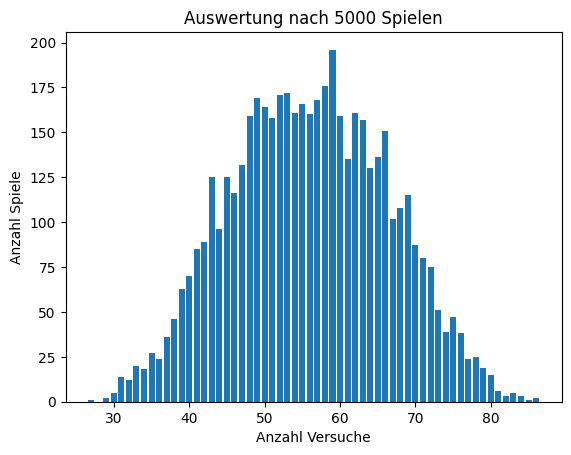

In [3]:
def ki_struktur(spielfeld):
    schiffliste = finde_schiffe(spielfeld)
    kandidatenliste = []
    for k in schiffliste:
        # links
        if k[1]-1>=0 and spielfeld[k[0]][k[1]-1]==0:
            kandidatenliste.append([k[0], k[1]-1])
        # rechts
        if k[1]+1<=9 and spielfeld[k[0]][k[1]+1]==0:
            kandidatenliste.append([k[0], k[1]+1])
        # oben
        if k[0]-1>=0 and spielfeld[k[0]-1][k[1]]==0:
            kandidatenliste.append([k[0]-1, k[1]])
        # unten
        if k[0]+1<=9 and spielfeld[k[0]+1][k[1]]==0:
            kandidatenliste.append([k[0]+1, k[1]])

    if len(kandidatenliste)>0:
        return kandidatenliste[0]

    zeilenzahl = random.randint(0,9)
    while 0 not in spielfeld[zeilenzahl]:
        zeilenzahl = random.randint(0,9)

    spaltenzahl = random.randint(0,9)
    while spielfeld[zeilenzahl][spaltenzahl] != 0:
        spaltenzahl = random.randint(0,9)

    return [zeilenzahl, spaltenzahl]

def finde_schiffe(feld):
    # Durchlaufe Zeilen und Spalten, merke dir Indizes, wo Schiffe stehen.
    output = []
    for zeilenzahl in range(len(feld)):
        for spaltenzahl in range(len(feld[zeilenzahl])):
            if feld[zeilenzahl][spaltenzahl]==1:
                output.append([zeilenzahl, spaltenzahl])
    return output

def unpadding(feld):
    # Rahmen mit Nullen
    #   feld: Spielfeld, Liste von Listen
    output = [[0 for i in range(10)] for j in range(10)]
    for i in range(10):
        for j in range(10): output[i][j] = feld[i+1][j+1]
    return output

def starte_spiel_ki_struktur(ki):
    spielfeld = reset_spielfeld()
    loesung = generiere_spielfeld()

    counter = 0
    while not spiel_ende(spielfeld, loesung):
        koordinaten = ki(spielfeld)
        counter+=1
        if loesung[koordinaten[0]][koordinaten[1]]==1:
            spielfeld[koordinaten[0]  ][koordinaten[1]  ] = 1
            p_feld = padding(spielfeld)
            p_feld[koordinaten[0]+2][koordinaten[1]+2] = 2
            p_feld[koordinaten[0]  ][koordinaten[1]+2] = 2
            p_feld[koordinaten[0]  ][koordinaten[1]  ] = 2
            p_feld[koordinaten[0]+2][koordinaten[1]  ] = 2
            spielfeld = unpadding(p_feld)

        else:
            spielfeld[koordinaten[0]][koordinaten[1]] = 2
    return counter

def auswertung(n_schritte):
    anzahldict = {}
    for i in range(n_schritte):
        anzahl = starte_spiel_ki_struktur(ki_struktur)
        if anzahl in anzahldict.keys():
            anzahldict[anzahl] += 1
        else:
            anzahldict[anzahl] = 1

    plt.figure()
    plt.title(f"Auswertung nach {n_schritte} Spielen")
    plt.bar(anzahldict.keys(), anzahldict.values())
    plt.xlabel("Anzahl Versuche")
    plt.ylabel("Anzahl Spiele")
    plt.show()

auswertung(5000)
#spielfeld = generiere_spielfeld()
#male_feld(spielfeld)
#print(finde_schiffe(spielfeld))
#print(starte_spiel_ki_struktur(ki_struktur))

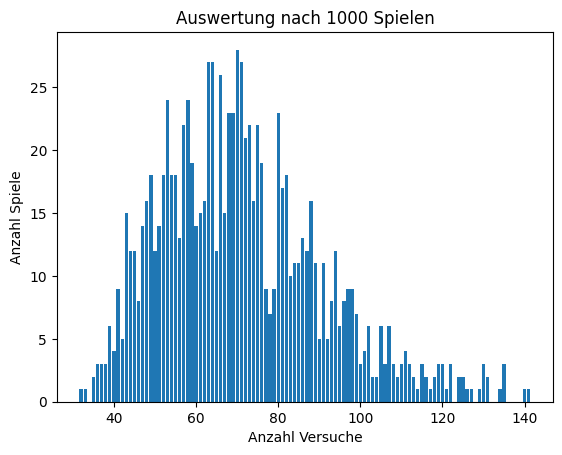

In [4]:
def ki_struktur(spielfeld):
    schiffliste = finde_schiffe(spielfeld)
    kandidatenliste = []
    for k in schiffliste:
        # links
        if k[1]-1>=0 and spielfeld[k[0]][k[1]-1]==0:
            kandidatenliste.append([k[0], k[1]-1])
        # rechts
        if k[1]+1<=9 and spielfeld[k[0]][k[1]+1]==0:
            kandidatenliste.append([k[0], k[1]+1])
        # oben
        if k[0]-1>=0 and spielfeld[k[0]-1][k[1]]==0:
            kandidatenliste.append([k[0]-1, k[1]])
        # unten
        if k[0]+1<=9 and spielfeld[k[0]+1][k[1]]==0:
            kandidatenliste.append([k[0]+1, k[1]])

    if len(kandidatenliste)>0:
        return kandidatenliste[0]

    zeilenzahl = random.randint(0,9)
    while 0 not in spielfeld[zeilenzahl][zeilenzahl%2::2]:
        #print(spielfeld[zeilenzahl][zeilenzahl%2::2])
        zeilenzahl = random.randint(0,9)

    spaltenzahl = random.randint(0,9)
    while spaltenzahl%2==zeilenzahl%2 and spielfeld[zeilenzahl][spaltenzahl] != 0:
        spaltenzahl = random.randint(0,9)

    return [zeilenzahl, spaltenzahl]

def finde_schiffe(feld):
    # Durchlaufe Zeilen und Spalten, merke dir Indizes, wo Schiffe stehen.
    output = []
    for zeilenzahl in range(len(feld)):
        for spaltenzahl in range(len(feld[zeilenzahl])):
            if feld[zeilenzahl][spaltenzahl]==1:
                output.append([zeilenzahl, spaltenzahl])
    return output

def unpadding(feld):
    # Rahmen mit Nullen
    #   feld: Spielfeld, Liste von Listen
    output = [[0 for i in range(10)] for j in range(10)]
    for i in range(10):
        for j in range(10): output[i][j] = feld[i+1][j+1]
    return output

def starte_spiel_ki_struktur(ki):
    spielfeld = reset_spielfeld()
    loesung = generiere_spielfeld()
    #male_feld(loesung)

    counter = 0
    while not spiel_ende(spielfeld, loesung):
        koordinaten = ki(spielfeld)
        counter+=1
        if loesung[koordinaten[0]][koordinaten[1]]==1:
            spielfeld[koordinaten[0]  ][koordinaten[1]  ] = 1
            p_feld = padding(spielfeld)
            p_feld[koordinaten[0]+2][koordinaten[1]+2] = 2
            p_feld[koordinaten[0]  ][koordinaten[1]+2] = 2
            p_feld[koordinaten[0]  ][koordinaten[1]  ] = 2
            p_feld[koordinaten[0]+2][koordinaten[1]  ] = 2
            spielfeld = unpadding(p_feld)

        else:
            spielfeld[koordinaten[0]][koordinaten[1]] = 2
    return counter

def auswertung(n_schritte):
    anzahldict = {}
    for i in range(n_schritte):
        anzahl = starte_spiel_ki_struktur(ki_struktur)
        if anzahl in anzahldict.keys():
            anzahldict[anzahl] += 1
        else:
            anzahldict[anzahl] = 1

    plt.figure()
    plt.title(f"Auswertung nach {n_schritte} Spielen")
    plt.bar(anzahldict.keys(), anzahldict.values())
    plt.xlabel("Anzahl Versuche")
    plt.ylabel("Anzahl Spiele")
    plt.show()

random.seed(0)
auswertung(1000)
#spielfeld = generiere_spielfeld()
#male_feld(spielfeld)
#print(finde_schiffe(spielfeld))
#print(starte_spiel_ki_struktur(ki_struktur))

  │ 1 2 3 4 5 6 7 8 9 0 │
──┼─────────────────────┼─
a │ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ │
b │ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ │
c │ s s s ~ ~ ~ ~ ~ ~ ~ │
d │ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ │
e │ ~ ~ ~ ~ ~ s ~ ~ ~ ~ │
f │ ~ ~ ~ s ~ s ~ ~ ~ ~ │
g │ ~ ~ ~ s ~ ~ ~ ~ ~ ~ │
h │ ~ ~ ~ s ~ ~ ~ ~ ~ ~ │
i │ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ │
j │ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ │
──┼─────────────────────┼─
[[0, 0], [0, 1], [0, 2], [0, 3], [0, 4], [0, 5], [0, 6], [0, 7], [1, 4], [1, 5], [1, 6], [1, 7], [2, 4], [2, 5], [2, 6], [2, 7], [3, 7], [4, 7], [5, 7], [6, 7], [7, 5], [7, 6], [7, 7], [8, 5], [8, 6], [8, 7], [9, 0], [9, 1], [9, 2], [9, 3], [9, 4], [9, 5], [9, 6], [9, 7]]


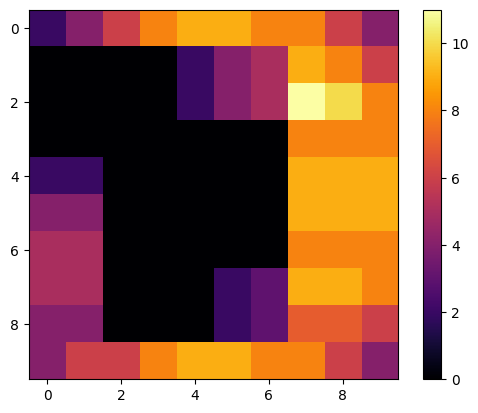

In [21]:
def likelihood(feld, pos, dir, l):
    for i in range(l):
        if dir==0:
            feld[pos[0]][pos[1]+i] += 1
        else:
            feld[pos[0]+i][pos[1]] += 1
    return feld

random.seed(0)
spielfeld = generiere_spielfeld([3,3,2])
male_feld(spielfeld)
print(erlaubt(spielfeld, 0, 3))

heatmap = reset_spielfeld()

for schifflaenge in [5,4]:
    for pos in erlaubt(spielfeld, 0, schifflaenge):
        heatmap = likelihood(heatmap, pos, 0, schifflaenge)
    for pos in erlaubt(spielfeld, 1, schifflaenge):
        heatmap = likelihood(heatmap, pos, 1, schifflaenge)

plt.figure()
plt.imshow(hilfsfeld, cmap="inferno")
plt.colorbar()
plt.show()

In [22]:
def argmax(feld):
    groesster_wert = -1
    position = []
    for zeile in range(10):
        for spalte in range(10):
            if feld[zeile][spalte]>groesster_wert:
                groesster_wert = feld[zeile][spalte]
                pos = [zeile, spalte]
    return pos

print(argmax(heatmap))

[2, 7]


In [ ]:
def ki_struktur(spielfeld):
    schiffliste = finde_schiffe(spielfeld)
    kandidatenliste = []
    for k in schiffliste:
        # links
        if k[1]-1>=0 and spielfeld[k[0]][k[1]-1]==0:
            kandidatenliste.append([k[0], k[1]-1])
        # rechts
        if k[1]+1<=9 and spielfeld[k[0]][k[1]+1]==0:
            kandidatenliste.append([k[0], k[1]+1])
        # oben
        if k[0]-1>=0 and spielfeld[k[0]-1][k[1]]==0:
            kandidatenliste.append([k[0]-1, k[1]])
        # unten
        if k[0]+1<=9 and spielfeld[k[0]+1][k[1]]==0:
            kandidatenliste.append([k[0]+1, k[1]])

    if len(kandidatenliste)>0:
        return kandidatenliste[0]

    heatmap = reset_spielfeld()

    for schifflaenge in [5,4]:
        for pos in erlaubt(spielfeld, 0, schifflaenge):
            heatmap = likelihood(heatmap, pos, 0, schifflaenge)
        for pos in erlaubt(spielfeld, 1, schifflaenge):
            heatmap = likelihood(heatmap, pos, 1, schifflaenge)

    return [zeilenzahl, spaltenzahl]

def finde_schiffe(feld):
    # Durchlaufe Zeilen und Spalten, merke dir Indizes, wo Schiffe stehen.
    output = []
    for zeilenzahl in range(len(feld)):
        for spaltenzahl in range(len(feld[zeilenzahl])):
            if feld[zeilenzahl][spaltenzahl]==1:
                output.append([zeilenzahl, spaltenzahl])
    return output

def unpadding(feld):
    # Rahmen mit Nullen
    #   feld: Spielfeld, Liste von Listen
    output = [[0 for i in range(10)] for j in range(10)]
    for i in range(10):
        for j in range(10): output[i][j] = feld[i+1][j+1]
    return output

def starte_spiel_ki_struktur(ki):
    spielfeld = reset_spielfeld()
    loesung = generiere_spielfeld()
    #male_feld(loesung)

    counter = 0
    while not spiel_ende(spielfeld, loesung):
        koordinaten = ki(spielfeld)
        counter+=1
        if loesung[koordinaten[0]][koordinaten[1]]==1:
            spielfeld[koordinaten[0]  ][koordinaten[1]  ] = 1
            p_feld = padding(spielfeld)
            p_feld[koordinaten[0]+2][koordinaten[1]+2] = 2
            p_feld[koordinaten[0]  ][koordinaten[1]+2] = 2
            p_feld[koordinaten[0]  ][koordinaten[1]  ] = 2
            p_feld[koordinaten[0]+2][koordinaten[1]  ] = 2
            spielfeld = unpadding(p_feld)

        else:
            spielfeld[koordinaten[0]][koordinaten[1]] = 2
    return counter

def auswertung(n_schritte):
    anzahldict = {}
    for i in range(n_schritte):
        anzahl = starte_spiel_ki_struktur(ki_struktur)
        if anzahl in anzahldict.keys():
            anzahldict[anzahl] += 1
        else:
            anzahldict[anzahl] = 1

    plt.figure()
    plt.title(f"Auswertung nach {n_schritte} Spielen")
    plt.bar(anzahldict.keys(), anzahldict.values())
    plt.xlabel("Anzahl Versuche")
    plt.ylabel("Anzahl Spiele")
    plt.show()

random.seed(0)
auswertung(1000)
#spielfeld = generiere_spielfeld()
#male_feld(spielfeld)
#print(finde_schiffe(spielfeld))
#print(starte_spiel_ki_struktur(ki_struktur))